# Written text as operational data

Written text is one type of data

### Why people write?

 - To communicate: their thoughts, feelings, urgency, needs, information

### Why people communicate?

1. To express emotions
1. To share information
1. To enable or elicit an action
1. ...

### We will use written text for the purpose other than 
1. To experience emotion
1. To learn something the author intended us to learn
1. To do what the author intended us to do

### Instead, we will use written text to recognize who wrote it
 - By calculating and comparing word frequencies in written documents
 
See, for example, likely fictional story https://medium.com/@amuse/how-the-nsa-caught-satoshi-nakamoto-868affcef595

### Example 1. Dictionaries in python (associative arrays)

Plot the frequency distribution of words on a web page.

In [27]:
import requests, re
# re is a module for regular expressions: to detect various combinations of characters
import operator

# Start from a simple document
r = requests .get('http://eecs.utk.edu', verify=False)

# What comes back includes headers and other HTTP stuff, get just the body of the response
t = r.text

# obtain words by splitting a string using as separator one or more (+) space/like characters (\s) 
wds = re.split('\s+',t)

# now populate a dictionary (wf)
wf = {}
for w in wds:
    if w in wf: wf [w] = wf [w] + 1
    else:  wf[w] = 1

# dictionaries can not be sorted, so lets get a sorted *list*        
wfs = sorted (wf .items(), key = operator .itemgetter (1), reverse=True)   

# lets just have no more than 15 words 
ml = min(len(wfs),15)
for i in range(1,ml,1):
    print (wfs[i][0]+"\t"+str(wfs[i][1]))  

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_333077/863724926.py:12: SyntaxWarning: invalid escape sequence '\s'
  wds = re.split('\s+',t)
/home/jacob/CodeSpace/.venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'eecs.utk.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


class="menu-item	64
menu-item-type-post_type	62
menu-item-object-page	62
<div	47
</div>	44
and	33
<a	29
/>	27
-->	26
of	25
<link	20
<!--	18
</li>	17
{	16


### Example 2

Lots of markup in the output, lets remove it --- 

use BeautifulSoup and nltk modules and practice some regular expressions.

In [28]:
import requests, re, nltk
from bs4 import BeautifulSoup
from nltk import clean_html
from collections import Counter
import operator

nltk.download('stopwords')#uncomment if not yet downloaded

# we may not care about the usage of stop words
stop_words = nltk.corpus.stopwords.words('english') + [
 'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
 '\"', '-', '}', '{', '&', '|', u'\u2014', '\.' ]

# We most likely would like to remove html markup
def cleanHtml (html):
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(html, 'html.parser')
    return soup .get_text()

# We also want to remove special characters, quotes, etc. from each word
def cleanWord (w):
    # r in r'[.,"\']' tells to treat \ as a regular character 
    # but we need to escape ' with \'
    # any character between the brackets [] is to be removed 
    wn = re.sub('[,"\.\'&\|:@>*;/=]', "", w)
    # get rid of numbers
    return re.sub('^[0-9\.]*$', "", wn)
       
# define a function to get text/clean/calculate frequency
def get_wf (URL):
    # first get the web page
    r = requests .get(URL)
    
    # Now clean
    # remove html markup
    t = cleanHtml (r .text) .lower()
    
    # split string into an array of words using any sequence of spaces "\s+" 
    wds = re .split('\s+',t)
    
    # remove periods, commas, etc stuck to the edges of words
    for i in range(len(wds)):
        wds [i] = cleanWord (wds [i])
    
    # If satisfied with results, lets go to the next step: calculate frequencies
    # We can write a loop to create a dictionary, but 
    # there is a special function for everything in python
    # in particular for counting frequencies (like function table() in R)
    wf = Counter (wds)
    
    # Remove stop words from the dictionary wf
    for k in stop_words:
        wf. pop(k, None)
        
    #how many regular words in the document?
    tw = 0
    for w in wf:
       tw += wf[w] 
        
    
    # Get ordered list
    wfs = sorted (wf .items(), key = operator.itemgetter(1), reverse=True)
    ml = min(len(wfs),15)

    #Reverse the list because barh plots items from the bottom
    return (wfs [ 0:ml ] [::-1], tw)
        
# Now populate two lists    
(wf_ee, tw_ee) = get_wf('http://www.gutenberg.org/ebooks/1342.txt.utf-8')
(wf_bu, tw_bu) = get_wf('http://www.gutenberg.org/ebooks/76.txt.utf-8')

<>:12: SyntaxWarning: invalid escape sequence '\.'
<>:25: SyntaxWarning: invalid escape sequence '\.'
<>:27: SyntaxWarning: invalid escape sequence '\.'
<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\.'
<>:25: SyntaxWarning: invalid escape sequence '\.'
<>:27: SyntaxWarning: invalid escape sequence '\.'
<>:39: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_333077/3708743421.py:12: SyntaxWarning: invalid escape sequence '\.'
  '\"', '-', '}', '{', '&', '|', u'\u2014', '\.' ]
/tmp/ipykernel_333077/3708743421.py:25: SyntaxWarning: invalid escape sequence '\.'
  wn = re.sub('[,"\.\'&\|:@>*;/=]', "", w)
/tmp/ipykernel_333077/3708743421.py:27: SyntaxWarning: invalid escape sequence '\.'
  return re.sub('^[0-9\.]*$', "", wn)
/tmp/ipykernel_333077/3708743421.py:39: SyntaxWarning: invalid escape sequence '\s'
  wds = re .split('\s+',t)
[nltk_data] Downloading package stopwords to /home/jacob/nltk_data...
[nltk_data]   Package stopw

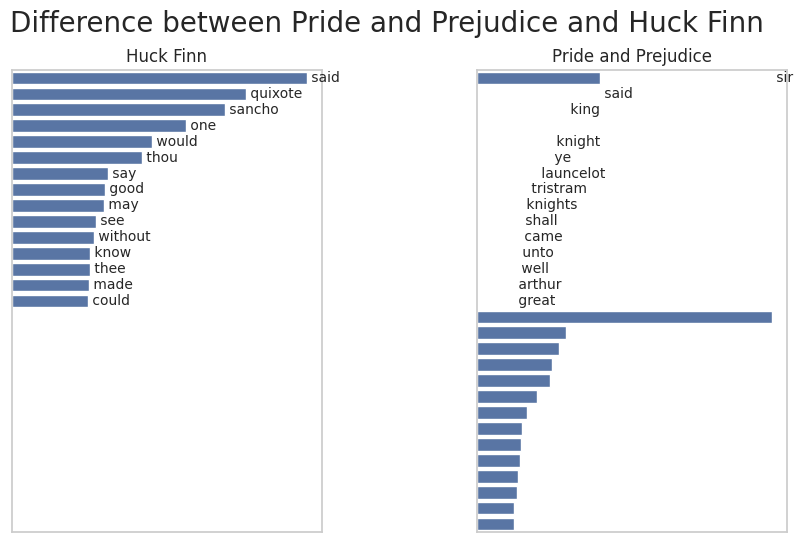

In [36]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plotTwoLists(wf_ee, wf_bu, title):
    sns.set(style="whitegrid")
    f, (ax2, ax1) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

    f.suptitle(title, fontsize=20)
    
    wf_bu_sorted = sorted(wf_bu, key=lambda x: x[1], reverse=True)
    wf_ee_sorted = sorted(wf_ee, key=lambda x: x[1], reverse=True)

    sns.barplot(x=[x[1] for x in wf_bu_sorted], y=[x[0] for x in wf_bu_sorted], ax=ax2)
    ax2.set_title("Huck Finn")
    ax2.set(ylabel='')

    sns.barplot(x=[x[1] for x in wf_ee_sorted], y=[x[0] for x in wf_ee_sorted], ax=ax1)
    ax1.set_title("Pride and Prejudice")
    ax2.set_yticklabels([])
    ax1.set_yticklabels([])

    # Adding words inside the bars
    for i, (word, freq) in enumerate(wf_bu_sorted):
        ax2.text(freq, i, f' {word}', va='center', fontsize=10)

    for i, (word, freq) in enumerate(wf_ee_sorted):
        ax1.text(freq, i, f' {word}', va='center', fontsize=10)

    # Remove larger axis labels and grid lines
    ax2.set_xticklabels([])
    ax1.set_xticklabels([])
    ax2.grid(False)
    ax1.grid(False)
    plt.subplots_adjust(wspace=0.5)

plotTwoLists(wf_ee, wf_bu, 'Difference between Pride and Prejudice and Huck Finn')

plt.show()


# 545 M1 Homework

1. Compare word frequencies between two works of a single author.
1. Compare word frequencies between works of two authors.
1. Are there some words preferred by one author but used less frequently by another author?
1. Reflect on the difference between the two authors. What is your interpretation?
1. Include each of the above as markdown cells. Upload a copy of your notebook and a rendering as .html or PDF.


Project Gutenberg is a good source of for fiction and non-fiction.

E.g below are two most popular books from Project Gutenberg:
- Pride and Prejudice at http://www.gutenberg.org/ebooks/1342.txt.utf-8
- Adventures of Huckleberry Finn at http://www.gutenberg.org/ebooks/76.txt.utf-8

In [30]:
import requests, re, nltk
#In case your text is not on Project Gutenberg but at some other URL
#http://www.fullbooks.com/Our-World-or-The-Slaveholders-Daughter2.html
# that contains 12 parts
t = ""
for i in range(2,13):
  r = requests .get('http://www.fullbooks.com/Our-World-or-The-Slaveholders-Daughter' + str(i) + '.html')
  t = t + r.text

In [31]:
len(t)

1323653

## Question 1: Two works of a single author.

1. The Illiad - Homer
2. The Odyssey - Homer

In [32]:

import requests, re, nltk
(wf_ee, tw_ee) = get_wf('http://www.gutenberg.org/ebooks/6150.txt.utf-8')
(wf_bu, tw_bu) = get_wf('http://www.gutenberg.org/ebooks/3160.txt.utf-8')

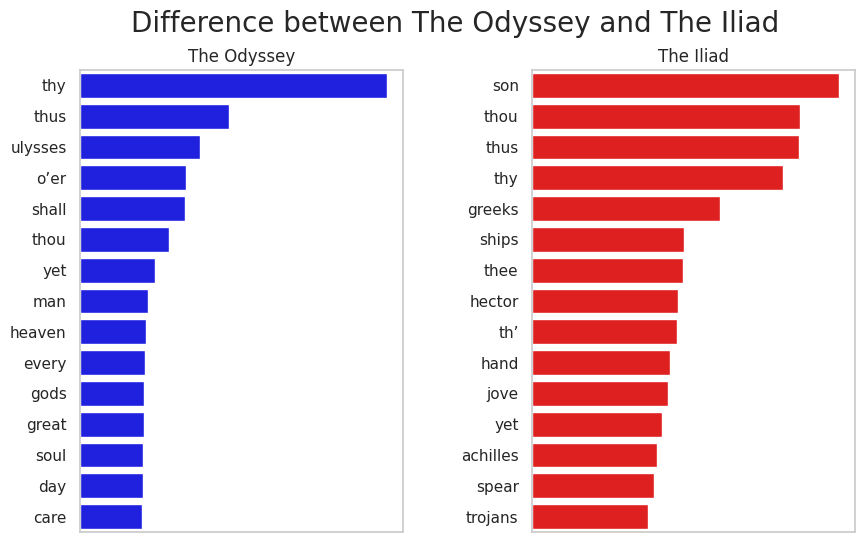

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plotTwoLists(wf_ee, wf_bu, title):
    sns.set(style="whitegrid")
    f, (ax2, ax1) = plt.subplots(1, 2, figsize=(10, 6), sharey=False)

    f.suptitle(title, fontsize=20)
    
    wf_bu_sorted = sorted(wf_bu, key=lambda x: x[1], reverse=True)
    wf_ee_sorted = sorted(wf_ee, key=lambda x: x[1], reverse=True)

    sns.barplot(x=[x[1] for x in wf_bu_sorted], y=[x[0] for x in wf_bu_sorted], ax=ax2, order=[x[0] for x in wf_bu_sorted], color="blue")
    ax2.set_title("The Odyssey")

    sns.barplot(x=[x[1] for x in wf_ee_sorted], y=[x[0] for x in wf_ee_sorted], ax=ax1, order=[x[0] for x in wf_ee_sorted], color="red")
    ax1.set_title("The Iliad")
# Optional: remove grids & ticks for cleaner look
    for ax in (ax1, ax2):
        ax.set_xticks([])
        ax.grid(False)

    plt.subplots_adjust(wspace=0.4)
    plt.show()
plotTwoLists(wf_ee, wf_bu, 'Difference between The Odyssey and The Iliad')



1. Compare word frequencies between two works of a single author.
1. Compare word frequencies between works of two authors.
1. Are there some words preferred by one author but used less frequently by another author?
1. Reflect on the difference between the two authors. What is your interpretation?
1. Include each of the above as markdown cells. Upload a copy of your notebook and a rendering as .html or PDF.

### Compare Word Frequencies

With Homer's writing, an interesting comparison is how many direct pronouns are used in The Odyssey when compared to The Iliad. The Iliad focuses more on the Trojan war, so the narrative focuses on different characters. With the Odyssey however, the setting is after the events of the war, and Odysseus is trying to return to Ithaca. The story takes place nearly exclusively around Odysseus and the interactions he has with gods and mythical beasts, so it makes sense fewer names and more pronouns directly referencing Odysseus or the others are more frequent.

## Question 2: Two works of different authors.

#### 1: Le Morte D' Arthur
#### 2: Don Quixote

In [34]:
import requests, re, nltk
(wf_ee, tw_ee) = get_wf('http://www.gutenberg.org/ebooks/46853.txt.utf-8')
(wf_bu, tw_bu) = get_wf('http://www.gutenberg.org/ebooks/996.txt.utf-8')

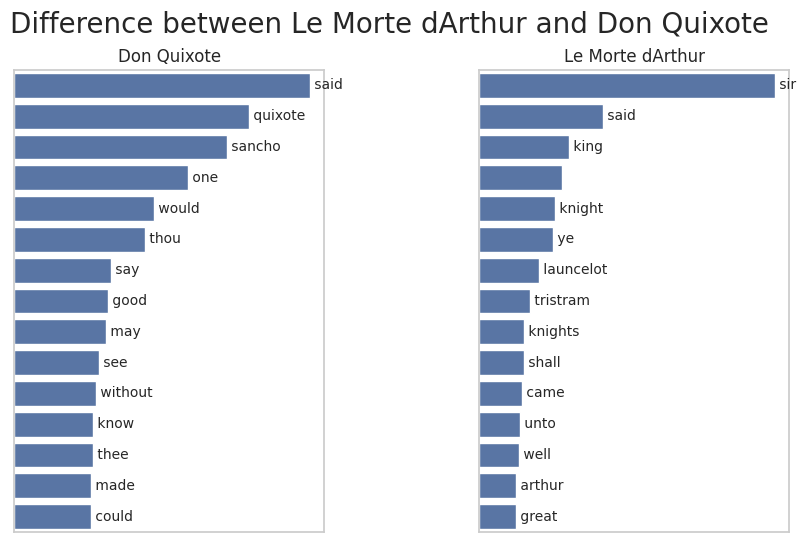

In [35]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plotTwoLists(wf_ee, wf_bu, title):
    sns.set(style="whitegrid")
    f, (ax2, ax1) = plt.subplots(1, 2, figsize=(10, 6), sharey=False)

    f.suptitle(title, fontsize=20)
    
    wf_bu_sorted = sorted(wf_bu, key=lambda x: x[1], reverse=True)
    wf_ee_sorted = sorted(wf_ee, key=lambda x: x[1], reverse=True)

    sns.barplot(x=[x[1] for x in wf_bu_sorted], y=[x[0] for x in wf_bu_sorted], ax=ax2)
    ax2.set_title("Don Quixote")
    ax2.set(ylabel='')

    sns.barplot(x=[x[1] for x in wf_ee_sorted], y=[x[0] for x in wf_ee_sorted], ax=ax1)
    ax1.set_title("Le Morte dArthur")
    ax2.set_yticklabels([])
    ax1.set_yticklabels([])

    # Adding words inside the bars
    for i, (word, freq) in enumerate(wf_bu_sorted):
        ax2.text(freq, i, f' {word}', va='center', fontsize=10)

    for i, (word, freq) in enumerate(wf_ee_sorted):
        ax1.text(freq, i, f' {word}', va='center', fontsize=10)

    # Remove larger axis labels and grid lines
    ax2.set_xticklabels([])
    ax1.set_xticklabels([])
    ax2.grid(False)
    ax1.grid(False)
    plt.subplots_adjust(wspace=0.5)

plotTwoLists(wf_ee, wf_bu, 'Difference between Le Morte dArthur and Don Quixote')

plt.show()

For comparing different authors, it is interesting during the 15th and 17th centuries, the authors of these world-famous books could only come up with "said" for dialogue. No other option rivals these for words describing dialogue. Another interesting comparison is the frequency of other characters in the stories. Some of the most featured words are "Sancho", "Tristram", and "Lancelot" which are all allies of the protagonists. With the two works, it is interesting how the authors use words to indirectly describe actions or characters. Quixote is the second most popular word which is the titular character's name, but Arthur is outranked by King and Sir.     